# DenseNet121 v3 — CBIS-DDSM Cropped (regression-fixed)

**v2 hit a regression** — AUC dropped 0.7622 → 0.7452, Phase-2 stopped at 9 / 35 epochs.
Diagnosis: 80 % of batches were MixUp/CutMix-mixed → too much label noise for subtle lesions, val_auc never recovered → early-stopping killed Phase 2 prematurely.

**v3 changes (vs v2):**
1. **Augmentation calmed down** — MixUp 50→15 %, CutMix 30→10 % (75 % of batches now see real images), Cutout 50→30 %, brightness ±15→±10 %, contrast 0.8–1.2→0.85–1.15.
2. **Focal-loss α 0.6 → 0.5** — neutral class balance (γ=2 already handles imbalance and the data isn't extremely skewed).
3. **Patience 8 → 15** — heavy aug needs longer to settle.
4. **Phase-2 LR 5e-5 → 3e-5** — gentler fine-tune.
5. **EMA enabled** — `AdamW(use_ema=True, ema_momentum=0.999)`; final weights are exponentially-averaged over the last ~10 epochs.
6. **EMA vs best-ckpt auto-selection** — after Phase 2 we evaluate both on `val_ds` and pick the winner.
7. **Phase 3 (optional polish)** — full backbone unfreeze (BN still frozen) at LR 1e-6 for 10 epochs with EMA.
8. **Threshold by balanced-accuracy** — instead of F1-max which biases heavily toward recall. Youden / F1-max / Bal-Acc all reported.
9. **Snapshot averaging** — top-3 best-AUC checkpoints are averaged for an SWA-lite boost.

In [1]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 1 ── Install + GPU + mixed precision + Drive
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

!pip install -q scikit-learn matplotlib seaborn opencv-python-headless

import tensorflow as tf
print("TensorFlow :", tf.__version__)
print("GPU        :", tf.config.list_physical_devices("GPU"))

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")
print("Compute policy:", mixed_precision.global_policy().name)

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Compute policy: mixed_float16
Mounted at /content/drive


In [2]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 2 ── Configuration  ← only edit this cell
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

import os, math, random, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, f1_score,
    precision_score, recall_score,
    precision_recall_curve, average_precision_score,
    matthews_corrcoef, balanced_accuracy_score,
)
from tensorflow.keras import layers, Model, callbacks, optimizers, regularizers
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")

# ── Paths ────────────────────────────────────────────────────────────────
JPEG_BASE  = Path("/content/drive/MyDrive/THESIS/cbis-ddsm/jpeg")
CSV_DIR    = Path("/content/drive/MyDrive/THESIS/cbis-ddsm/csv")
OUTPUT_DIR = Path("/content/drive/MyDrive/THESIS/cbis-ddsm/cropped_split")

SPLIT_DIR = OUTPUT_DIR
TRAIN_DIR = SPLIT_DIR / "train"
VAL_DIR   = SPLIT_DIR / "val"
TEST_DIR  = SPLIT_DIR / "test"

SAVE_DIR = Path("/content/drive/MyDrive/THESIS/cbis-ddsm/model_output/densenet121_v3")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ── Image / batch settings ───────────────────────────────────────────────
IMG_SIZE     = 320
RESIZE_SIZE  = 360
CHANNELS     = 3
BATCH_SIZE   = 24

# ── Training schedule ────────────────────────────────────────────────────
PHASE1_EPOCHS  = 12
PHASE2_EPOCHS  = 40   # ↑ from 35
PHASE3_EPOCHS  = 10   # NEW — full-unfreeze polish
WARMUP_EPOCHS  = 2    # ↓ from 3 (faster ramp)
PHASE3_WARMUP  = 1

PHASE1_BASE_LR = 1e-3
PHASE2_BASE_LR = 3e-5   # ↓ from 5e-5
PHASE3_BASE_LR = 1e-6   # tiny — full backbone polish
WEIGHT_DECAY   = 1e-4
EMA_MOMENTUM   = 0.999

# ── Regularisation ───────────────────────────────────────────────────────
DROPOUT_RATE = 0.4    # ↓ from 0.5
L2_REG       = 1e-5

# ── Loss ─────────────────────────────────────────────────────────────────
FOCAL_GAMMA      = 2.0
FOCAL_ALPHA      = 0.5    # ↓ from 0.6 — let γ handle the imbalance
LABEL_SMOOTHING  = 0.05

# ── Augmentation strengths ───────────────────────────────────────────────
MIXUP_ALPHA   = 0.2
CUTMIX_ALPHA  = 1.0
MIX_PROB      = 0.15   # ↓ from 0.50
CUTMIX_PROB   = 0.10   # ↓ from 0.30  →  75 % of batches now see real images
CUTOUT_PROB   = 0.30   # ↓ from 0.50
CUTOUT_SIZE   = 48
BRIGHTNESS_DELTA = 0.10 * 255.0   # ↓ from 0.15·255
CONTRAST_LO, CONTRAST_HI = 0.85, 1.15   # tighter than 0.8–1.2

# ── Fine-tuning policy ───────────────────────────────────────────────────
UNFREEZE_LAYERS = 120

# ── TTA ──────────────────────────────────────────────────────────────────
TTA_STEPS = 8

# ── Snapshot averaging ───────────────────────────────────────────────────
TOP_K_SNAPSHOTS = 3

# ── Reproducibility ──────────────────────────────────────────────────────
RANDOM_SEED = 42
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

print("=" * 70)
print("  DenseNet121 v3 — Breast Cancer Classification (regression-fixed)")
print("=" * 70)
print(f"  Save dir    : {SAVE_DIR}")
print(f"  Image size  : {IMG_SIZE}×{IMG_SIZE}  (resize {RESIZE_SIZE} + crop)")
print(f"  Batch size  : {BATCH_SIZE}")
print(f"  Phase 1 / 2 / 3 epochs : {PHASE1_EPOCHS} / {PHASE2_EPOCHS} / {PHASE3_EPOCHS}")
print(f"  LRs         : phase1 {PHASE1_BASE_LR} | phase2 {PHASE2_BASE_LR} | phase3 {PHASE3_BASE_LR}")
print(f"  Mix prob    : MixUp {MIX_PROB:.2f} + CutMix {CUTMIX_PROB:.2f} (was 0.50 + 0.30)")
print(f"  Focal       : γ={FOCAL_GAMMA} α={FOCAL_ALPHA} smooth={LABEL_SMOOTHING}")
print(f"  EMA momentum: {EMA_MOMENTUM}  |  TTA steps: {TTA_STEPS}  |  Top-K snap: {TOP_K_SNAPSHOTS}")

  DenseNet121 v3 — Breast Cancer Classification (regression-fixed)
  Save dir    : /content/drive/MyDrive/THESIS/cbis-ddsm/model_output/densenet121_v3
  Image size  : 320×320  (resize 360 + crop)
  Batch size  : 24
  Phase 1 / 2 / 3 epochs : 12 / 40 / 10
  LRs         : phase1 0.001 | phase2 3e-05 | phase3 1e-06
  Mix prob    : MixUp 0.15 + CutMix 0.10 (was 0.50 + 0.30)
  Focal       : γ=2.0 α=0.5 smooth=0.05
  EMA momentum: 0.999  |  TTA steps: 8  |  Top-K snap: 3


In [3]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 3 ── Dataset inspection
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("▶  STEP 1 — Dataset inspection …\n")
stats = {}
for split in ["train", "val", "test"]:
    sp = SPLIT_DIR / split
    counts = {}
    for label in ["malignant", "benign"]:
        p = sp / label
        counts[label] = (
            len(list(p.glob("*.jpg")) + list(p.glob("*.jpeg")) + list(p.glob("*.png")))
            if p.exists() else 0
        )
    stats[split] = counts

print(f"  {'Split':<8} {'Malignant':>10} {'Benign':>8} {'Total':>7}  Mal%")
print(f"  {'─'*42}")
for split, cnt in stats.items():
    mal, ben = cnt["malignant"], cnt["benign"]
    total    = mal + ben
    pct      = mal / total * 100 if total > 0 else 0.0
    print(f"  {split:<8} {mal:>10,} {ben:>8,} {total:>7,}  {pct:.1f}%")

▶  STEP 1 — Dataset inspection …

  Split     Malignant   Benign   Total  Mal%
  ──────────────────────────────────────────
  train         1,004    1,472   2,476  40.5%
  val             231      340     571  40.5%
  test            215      287     502  42.8%


In [4]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 4 ── Preprocessing & augmentation  (calmed-down vs v2)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("▶  STEP 2 — Building preprocessing & augmentation pipelines …\n")

def apply_clahe(image_np):
    if image_np.ndim == 2 or image_np.shape[2] == 1:
        img_u8    = image_np.squeeze().astype(np.uint8)
        clahe     = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
        equalized = clahe.apply(img_u8)
        return np.stack([equalized] * 3, axis=-1)
    lab     = cv2.cvtColor(image_np.astype(np.uint8), cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe   = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    l_eq    = clahe.apply(l)
    return cv2.cvtColor(cv2.merge([l_eq, a, b]), cv2.COLOR_LAB2RGB)

def _decode_resize_clahe(image_path, size):
    raw   = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(raw, channels=CHANNELS)
    image = tf.image.resize(image, [size, size], method="bilinear")
    image = tf.cast(image, tf.uint8)
    image = tf.py_function(
        func=lambda img: apply_clahe(img.numpy()),
        inp=[image], Tout=tf.uint8,
    )
    image.set_shape([size, size, 3])
    return tf.cast(image, tf.float32)

def random_cutout(image, size=CUTOUT_SIZE):
    H = tf.shape(image)[0]; W = tf.shape(image)[1]
    cy = tf.random.uniform([], 0, H, dtype=tf.int32)
    cx = tf.random.uniform([], 0, W, dtype=tf.int32)
    half = size // 2
    y1 = tf.maximum(0, cy - half); y2 = tf.minimum(H, cy + half)
    x1 = tf.maximum(0, cx - half); x2 = tf.minimum(W, cx + half)
    yy = tf.range(H)[:, None]; xx = tf.range(W)[None, :]
    mask = (yy >= y1) & (yy < y2) & (xx >= x1) & (xx < x2)
    mask = tf.cast(mask, image.dtype)[..., None]
    return image * (1.0 - mask)

def preprocess_image_train(image_path, label):
    image = _decode_resize_clahe(image_path, RESIZE_SIZE)
    image = tf.image.random_crop(image, [IMG_SIZE, IMG_SIZE, 3])
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=BRIGHTNESS_DELTA)
    image = tf.image.random_contrast(image, lower=CONTRAST_LO, upper=CONTRAST_HI)
    image = tf.clip_by_value(image, 0.0, 255.0)
    image = preprocess_input(image)
    noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=0.015)   # ↓ from 0.02
    image = image + noise
    do_cut = tf.random.uniform([], 0.0, 1.0) < CUTOUT_PROB
    image  = tf.cond(do_cut, lambda: random_cutout(image), lambda: image)
    image  = tf.clip_by_value(image, -2.5, 2.5)
    return image, tf.cast(label, tf.float32)

def preprocess_image_val(image_path, label):
    image = _decode_resize_clahe(image_path, RESIZE_SIZE)
    off = (RESIZE_SIZE - IMG_SIZE) // 2
    image = image[off:off+IMG_SIZE, off:off+IMG_SIZE, :]
    image.set_shape([IMG_SIZE, IMG_SIZE, 3])
    image = preprocess_input(image)
    return image, tf.cast(label, tf.float32)

def make_tta_view(image_path, label, tta_id):
    image = _decode_resize_clahe(image_path, RESIZE_SIZE)
    off = (RESIZE_SIZE - IMG_SIZE) // 2
    image = image[off:off+IMG_SIZE, off:off+IMG_SIZE, :]
    image.set_shape([IMG_SIZE, IMG_SIZE, 3])
    def apply_tta(img, t):
        img = tf.cond(tf.equal(t, 1), lambda: tf.image.flip_left_right(img), lambda: img)
        img = tf.cond(tf.equal(t, 2), lambda: tf.image.flip_up_down(img),    lambda: img)
        img = tf.cond(tf.equal(t, 3),
                      lambda: tf.image.flip_up_down(tf.image.flip_left_right(img)),
                      lambda: img)
        img = tf.cond(tf.equal(t, 4), lambda: tf.image.rot90(img, k=1), lambda: img)
        img = tf.cond(tf.equal(t, 5), lambda: tf.image.rot90(img, k=2), lambda: img)
        img = tf.cond(tf.equal(t, 6), lambda: tf.image.rot90(img, k=3), lambda: img)
        img = tf.cond(tf.equal(t, 7),
                      lambda: tf.image.rot90(tf.image.flip_left_right(img), k=1),
                      lambda: img)
        return img
    image = apply_tta(image, tta_id)
    image = preprocess_input(image)
    return image, tf.cast(label, tf.float32)

def _sample_beta(alpha):
    g1 = tf.random.gamma([], alpha); g2 = tf.random.gamma([], alpha)
    return g1 / (g1 + g2 + 1e-8)

def mixup(images, labels, alpha=MIXUP_ALPHA):
    bs = tf.shape(images)[0]
    lam = _sample_beta(alpha); lam = tf.maximum(lam, 1.0 - lam)
    idx = tf.random.shuffle(tf.range(bs))
    img2 = tf.gather(images, idx); lbl2 = tf.gather(labels, idx)
    lam_img = tf.cast(lam, images.dtype); lam_lbl = tf.cast(lam, labels.dtype)
    return lam_img*images + (1-lam_img)*img2, lam_lbl*labels + (1-lam_lbl)*lbl2

def cutmix(images, labels, alpha=CUTMIX_ALPHA):
    bs = tf.shape(images)[0]; H = tf.shape(images)[1]; W = tf.shape(images)[2]
    lam = _sample_beta(alpha)
    cut_ratio = tf.sqrt(1.0 - lam)
    cut_h = tf.cast(tf.cast(H, tf.float32) * cut_ratio, tf.int32)
    cut_w = tf.cast(tf.cast(W, tf.float32) * cut_ratio, tf.int32)
    cy = tf.random.uniform([], 0, H, dtype=tf.int32)
    cx = tf.random.uniform([], 0, W, dtype=tf.int32)
    y1 = tf.maximum(0, cy - cut_h//2); y2 = tf.minimum(H, cy + cut_h//2)
    x1 = tf.maximum(0, cx - cut_w//2); x2 = tf.minimum(W, cx + cut_w//2)
    yy = tf.range(H)[:, None]; xx = tf.range(W)[None, :]
    mask = (yy >= y1) & (yy < y2) & (xx >= x1) & (xx < x2)
    mask = tf.cast(mask, images.dtype)[None, ..., None]
    idx = tf.random.shuffle(tf.range(bs))
    img2 = tf.gather(images, idx); lbl2 = tf.gather(labels, idx)
    mixed = images*(1.0-mask) + img2*mask
    cut_area = tf.cast((y2-y1)*(x2-x1), tf.float32)
    actual_lam = 1.0 - cut_area / tf.cast(H*W, tf.float32)
    actual_lam = tf.cast(actual_lam, labels.dtype)
    return mixed, actual_lam*labels + (1.0-actual_lam)*lbl2

def mix_or_keep(images, labels):
    """15 % MixUp · 10 % CutMix · 75 % no-mix  (was 50/30/20 in v2)"""
    r = tf.random.uniform([], 0.0, 1.0)
    return tf.cond(
        r < MIX_PROB,
        lambda: mixup(images, labels),
        lambda: tf.cond(
            r < MIX_PROB + CUTMIX_PROB,
            lambda: cutmix(images, labels),
            lambda: (images, labels),
        ),
    )

print("  ✔ CLAHE (clip 2.5, 8×8 grid)")
print(f"  ✔ Train aug — calmed: brightness ±{BRIGHTNESS_DELTA/255:.2f}, contrast {CONTRAST_LO}-{CONTRAST_HI},")
print(f"               cutout {CUTOUT_PROB*100:.0f}%, mix {MIX_PROB*100:.0f}%, cutmix {CUTMIX_PROB*100:.0f}%")
print(f"  ✔ TTA       — {TTA_STEPS} deterministic flips/rotations averaged")

▶  STEP 2 — Building preprocessing & augmentation pipelines …

  ✔ CLAHE (clip 2.5, 8×8 grid)
  ✔ Train aug — calmed: brightness ±0.10, contrast 0.85-1.15,
               cutout 30%, mix 15%, cutmix 10%
  ✔ TTA       — 8 deterministic flips/rotations averaged


In [5]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 5 ── tf.data datasets
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n▶  STEP 3 — Building tf.data pipelines …")
IMG_EXTS = (".jpg", ".jpeg", ".png")

def collect_paths_labels(split_path):
    paths, labels = [], []
    for label_name, label_val in [("malignant", 1), ("benign", 0)]:
        folder = split_path / label_name
        if not folder.exists():
            print(f"  ⚠  Folder not found: {folder}"); continue
        for f in sorted(folder.iterdir()):
            if f.suffix.lower() in IMG_EXTS:
                paths.append(str(f)); labels.append(label_val)
    return paths, labels

def make_train_ds(split_path):
    paths, lbls = collect_paths_labels(split_path); n = len(paths)
    ds = tf.data.Dataset.from_tensor_slices((tf.constant(paths), tf.constant(lbls, dtype=tf.int32)))
    ds = ds.shuffle(buffer_size=n, seed=RANDOM_SEED, reshuffle_each_iteration=True)
    ds = ds.map(preprocess_image_train, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE, drop_remainder=True)
    ds = ds.map(mix_or_keep, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds, n, paths, lbls

def make_eval_ds(split_path):
    paths, lbls = collect_paths_labels(split_path); n = len(paths)
    ds = tf.data.Dataset.from_tensor_slices((tf.constant(paths), tf.constant(lbls, dtype=tf.int32)))
    ds = ds.map(preprocess_image_val, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds, n, paths, lbls

def make_tta_ds(split_path, tta_id):
    paths, lbls = collect_paths_labels(split_path)
    ds = tf.data.Dataset.from_tensor_slices((tf.constant(paths), tf.constant(lbls, dtype=tf.int32)))
    ds = ds.map(lambda p, l: make_tta_view(p, l, tta_id), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds, n_train, _, _           = make_train_ds(TRAIN_DIR)
val_ds,   n_val,   _, val_labels  = make_eval_ds(VAL_DIR)
test_ds,  n_test,  test_paths, test_labels = make_eval_ds(TEST_DIR)

steps_per_epoch = n_train // BATCH_SIZE
print(f"  Train : {n_train:,}  ({steps_per_epoch} steps/epoch)")
print(f"  Val   : {n_val:,}")
print(f"  Test  : {n_test:,}")


▶  STEP 3 — Building tf.data pipelines …
  Train : 2,476  (103 steps/epoch)
  Val   : 571
  Test  : 502


In [6]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 6 ── DenseNet121  (concat-pool head)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n▶  STEP 4 — Building DenseNet121 …\n")

def build_model(trainable_backbone=False):
    base = DenseNet121(weights="imagenet", include_top=False,
                       input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS))
    base.trainable = trainable_backbone
    inputs = base.input
    feat   = base.output
    gap = layers.GlobalAveragePooling2D(name="gap")(feat)
    gmp = layers.GlobalMaxPooling2D(name="gmp")(feat)
    x   = layers.Concatenate(name="concat_pool")([gap, gmp])
    x   = layers.BatchNormalization(name="bn1")(x)
    x   = layers.Dropout(DROPOUT_RATE, name="drop1")(x)
    x   = layers.Dense(512, activation="swish",
                       kernel_regularizer=regularizers.l2(L2_REG),
                       kernel_initializer="he_normal", name="fc1")(x)
    x   = layers.BatchNormalization(name="bn2")(x)
    x   = layers.Dropout(0.3, name="drop2")(x)
    x   = layers.Dense(128, activation="swish",
                       kernel_regularizer=regularizers.l2(L2_REG),
                       kernel_initializer="he_normal", name="fc2")(x)
    x   = layers.Dropout(0.2, name="drop3")(x)
    out = layers.Dense(1, activation="sigmoid", dtype="float32", name="output")(x)
    return Model(inputs=inputs, outputs=out, name="DenseNet121_BC_v3")

model = build_model(trainable_backbone=False)
model.summary(line_length=85, show_trainable=True)
print(f"\n  Trainable: {sum(tf.size(w).numpy() for w in model.trainable_weights):,}")
print(f"  Total    : {sum(tf.size(w).numpy() for w in model.weights):,}")


▶  STEP 4 — Building DenseNet121 …

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "DenseNet121_BC_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃     Param # ┃ Connected to     ┃ Train… ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│ input_layer         │ (None, 320, 320,  │           0 │ -                │   -    │
│ (InputLayer)        │ 3)                │             │                  │        │
├─────────────────────┼───────────────────┼─────────────┼──────────────────┼────────┤
│ zero_padding2d      │ (None, 326, 326,  │           0 │ input_layer[0][… │   -    │
│ (ZeroPadding2D)     │ 3)                │             │                  │        │
├─────────────────────┼───────────────────┼─────────────┼──────────────────┼────────┤
│ conv1_conv (Conv2D) │ (None, 160, 160,  │       9,408 │ zero_padding2d[… │   N    │
│                     │ 64)               │             │                  │        │
├─────────────────────┼───────────────────┼─────────────┼──────────────────┼────────┤
│ conv1_bn            │ (None, 160, 160,  │         256 │ conv1_conv[0][0] │   N    │
│ (BatchNormalizatio… │ 64)               │             │                  │        │
├─────────────────────┼───────────────────┼─────────────┼──────────────────┼────────┤
│ conv1_relu          │ (None, 160, 160,  │           0 │ conv1_bn[0][0]   │   -    │
│ (Activation)        │ 64)               │             │                  │        │
├─────────────────────┼───────────────────┼─────────────┼──────────────────┼────────┤
│ zero_padding2d_1    │ (None, 162, 162,  │           0 │ conv1_relu[0][0] │   -    │
│ (ZeroPadding2D)     │ 64)               │             │                  │        │
├─────────────────────┼───────────────────┼─────────────┼──────────────────┼────────┤
│ pool1               │ (None, 80, 80,    │           0 │ zero_padding2d_… │   -    │
│ (MaxPooling2D)      │ 64)               │             │                  │        │
├─────────────────────┼───────────────────┼─────────────┼──────────────────┼────────┤
│ conv2_block1_0_bn   │ (None, 80, 80,    │         256 │ pool1[0][0]      │   N    │
│ (BatchNormalizatio… │ 64)               │             │                  │        │
├─────────────────────┼───────────────────┼─────────────┼──────────────────┼────────┤
│ conv2_block1_0_relu │ (None, 80, 80,    │           0 │ conv2_block1_0_… │   -    │
│ (Activation)        │ 64)               │             │                  │        │
├─────────────────────┼───────────────────┼─────────────┼──────────────────┼────────┤
│ conv2_block1_1_conv │ (None, 80, 80,    │       8,192 │ conv2_block1_0_… │   N    │
│ (Conv2D)            │ 128)              │             │                  │        │
├─────────────────────┼───────────────────┼─────────────┼──────────────────┼────────┤
│ conv2_block1_1_bn   │ (None, 80, 80,    │         512 │ conv2_block1_1_… │   N    │
│ (BatchNormalizatio… │ 128)              │             │                  │        │
├─────────────────────┼───────────────────┼─────────────┼──────────────────┼────────┤
│ conv2_block1_1_relu │ (None, 80, 80,    │           0 │ conv2_block1_1_… │   -    │
│ (Activation)        │ 128)              │             │                  │        │
├─────────────────────┼───────────────────┼─────────────┼──────────────────┼────────┤
│ conv2_block1_2_conv │ (None, 80, 80,    │      36,864 │ conv2_block1_1_… │   N    │
│ (Conv2D)            │ 32)               │             │                  │        │
├─────────────────────┼───────────────────┼─────────────┼──────────────────┼────────┤
│ conv2_block1_concat │ (None, 80, 80,    │           0 │ pool1[0][0],     │   -    │
│ (Concatenate)       │ 96)               │             │ conv2_block1_2_… │        │
├─────────────────────┼───────────────────┼─────────────┼──────────────────┼────────┤
│ conv2_block2_0_bn   │ (None, 80, 80,    │         384 │ conv2_block1_co… │   N    │
│ (BatchNormalizatio… │ 96)               │ 

 Total params: 8,162,625 (31.14 MB)

 Trainable params: 1,120,001 (4.27 MB)

 Non-trainable params: 7,042,624 (26.87 MB)


  Trainable: 1,120,001
  Total    : 8,162,625


In [7]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 7 ── Loss + LR schedule + Top-K snapshot callback
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

class WarmUpCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr, total_steps, warmup_steps, min_lr_factor=0.01):
        super().__init__()
        self.base_lr=float(base_lr); self.total_steps=float(total_steps)
        self.warmup_steps=float(warmup_steps); self.min_lr_factor=float(min_lr_factor)
    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup_lr = self.base_lr * (step / tf.maximum(1.0, self.warmup_steps))
        progress  = (step - self.warmup_steps) / tf.maximum(1.0, self.total_steps - self.warmup_steps)
        progress  = tf.clip_by_value(progress, 0.0, 1.0)
        cosine    = 0.5 * (1.0 + tf.cos(math.pi * progress))
        cosine_lr = self.base_lr * (self.min_lr_factor + (1.0 - self.min_lr_factor) * cosine)
        return tf.where(step < self.warmup_steps, warmup_lr, cosine_lr)
    def get_config(self):
        return dict(base_lr=self.base_lr, total_steps=self.total_steps,
                    warmup_steps=self.warmup_steps, min_lr_factor=self.min_lr_factor)

focal_loss = tf.keras.losses.BinaryFocalCrossentropy(
    apply_class_balancing=True, alpha=FOCAL_ALPHA,
    gamma=FOCAL_GAMMA, label_smoothing=LABEL_SMOOTHING, from_logits=False,
)
metrics_list = [
    "accuracy",
    tf.keras.metrics.AUC(name="auc",    curve="ROC"),
    tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall"),
]

class TopKSnapshotter(tf.keras.callbacks.Callback):
    """Save top-K best-val_auc checkpoints during training (for snapshot averaging)."""
    def __init__(self, save_dir, k=3, monitor="val_auc", prefix="snap"):
        super().__init__()
        self.save_dir = Path(save_dir); self.save_dir.mkdir(parents=True, exist_ok=True)
        self.k = k; self.monitor = monitor; self.prefix = prefix
        self.snapshots = []   # list of (score, path)
    def on_epoch_end(self, epoch, logs=None):
        score = logs.get(self.monitor)
        if score is None: return
        path = str(self.save_dir / f"{self.prefix}_e{epoch+1:02d}_{score:.4f}.weights.h5")
        if len(self.snapshots) < self.k:
            self.model.save_weights(path); self.snapshots.append((score, path))
            self.snapshots.sort(key=lambda t: t[0])
        else:
            worst_score, worst_path = self.snapshots[0]
            if score > worst_score:
                try: os.remove(worst_path)
                except: pass
                self.model.save_weights(path)
                self.snapshots[0] = (score, path)
                self.snapshots.sort(key=lambda t: t[0])
    def get_paths(self):
        return [p for _, p in sorted(self.snapshots, key=lambda t: -t[0])]

def average_weights(model, weight_paths):
    """Load each weight file, average them in-place into the model."""
    if not weight_paths: return
    accumulated = None
    for p in weight_paths:
        model.load_weights(p)
        ws = [w.numpy() for w in model.weights]
        if accumulated is None:
            accumulated = ws
        else:
            accumulated = [a + w for a, w in zip(accumulated, ws)]
    averaged = [a / len(weight_paths) for a in accumulated]
    model.set_weights(averaged)

print("  ✔ WarmUpCosine, focal-BCE (α=0.5, γ=2), Top-K snapshotter, weight averager")

  ✔ WarmUpCosine, focal-BCE (α=0.5, γ=2), Top-K snapshotter, weight averager


In [8]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 8 ── Phase 1: head training (frozen backbone)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n▶  STEP 5 — Phase 1: train head …\n")

phase1_ckpt = str(SAVE_DIR / "phase1_best.weights.h5")
p1_total = steps_per_epoch * PHASE1_EPOCHS
p1_warm  = steps_per_epoch * 1
lr_p1 = WarmUpCosine(PHASE1_BASE_LR, p1_total, p1_warm)

model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=lr_p1, weight_decay=WEIGHT_DECAY, clipnorm=1.0),
    loss=focal_loss, metrics=metrics_list,
)

cb_p1 = [
    callbacks.ModelCheckpoint(phase1_ckpt, monitor="val_auc", mode="max",
                               save_best_only=True, save_weights_only=True, verbose=1),
    callbacks.EarlyStopping(monitor="val_auc", patience=8, mode="max",
                             restore_best_weights=True, verbose=1),
    callbacks.CSVLogger(str(SAVE_DIR / "phase1_history.csv")),
    callbacks.TerminateOnNaN(),
]

history_p1 = model.fit(train_ds, epochs=PHASE1_EPOCHS,
                        validation_data=val_ds, callbacks=cb_p1, verbose=1)
model.load_weights(phase1_ckpt)
print(f"\n  ✔ Phase 1 best weights → {phase1_ckpt}")


▶  STEP 5 — Phase 1: train head …

Epoch 1/12
102/103 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.4738 - auc: 0.5428 - loss: 0.2555 - pr_auc: 0.4792 - precision: 0.4952 - recall: 0.5637
Epoch 1: val_auc improved from None to 0.68048, saving model to /content/drive/MyDrive/THESIS/cbis-ddsm/model_output/densenet121_v3/phase1_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/THESIS/cbis-ddsm/model_output/densenet121_v3/phase1_best.weights.h5
103/103 ━━━━━━━━━━━━━━━━━━━━ 125s 752ms/step - accuracy: 0.4834 - auc: 0.5726 - loss: 0.2174 - pr_auc: 0.5185 - precision: 0.5245 - recall: 0.5102 - val_accuracy: 0.6287 - val_auc: 0.6805 - val_loss: 0.1445 - val_pr_auc: 0.5497 - val_precision: 0.5760 - val_recall: 0.3117
Epoch 2/12
102/103 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.5240 - auc: 0.6230 - loss: 0.1766 - pr_auc: 0.5750 - precision: 0.5736 - recall: 0.4896
Epoch 2: val_auc did not improve from 0.68048
103/103 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - accurac

In [9]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 9 ── Phase 2: progressive fine-tune  (last 120 layers, BN frozen)
#           AdamW + EMA + Top-K snapshot averaging
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n▶  STEP 6 — Phase 2: fine-tune last 120 layers (EMA + snapshot avg) …\n")

CUSTOM_HEAD_NAMES = {"gap", "gmp", "concat_pool",
                      "bn1", "drop1", "fc1",
                      "bn2", "drop2", "fc2", "drop3", "output"}
backbone_layers = [l for l in model.layers if l.name not in CUSTOM_HEAD_NAMES]

for layer in backbone_layers: layer.trainable = False
to_unfreeze = backbone_layers[-UNFREEZE_LAYERS:]
n_unfrozen = n_bn = 0
for layer in to_unfreeze:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False; n_bn += 1
    else:
        layer.trainable = True; n_unfrozen += 1
print(f"  Unfrozen non-BN: {n_unfrozen}  |  BN frozen: {n_bn}")

p2_total = steps_per_epoch * PHASE2_EPOCHS
p2_warm  = steps_per_epoch * WARMUP_EPOCHS
lr_p2 = WarmUpCosine(PHASE2_BASE_LR, p2_total, p2_warm)

optimizer_p2 = tf.keras.optimizers.AdamW(
    learning_rate=lr_p2, weight_decay=WEIGHT_DECAY, clipnorm=1.0,
    use_ema=True, ema_momentum=EMA_MOMENTUM,    # ← KEY v3 ADDITION
)
model.compile(optimizer=optimizer_p2, loss=focal_loss, metrics=metrics_list)

phase2_ckpt    = str(SAVE_DIR / "phase2_best.weights.h5")
snap_dir       = SAVE_DIR / "snapshots_p2"
snapper        = TopKSnapshotter(snap_dir, k=TOP_K_SNAPSHOTS, prefix="p2")

cb_p2 = [
    callbacks.ModelCheckpoint(phase2_ckpt, monitor="val_auc", mode="max",
                               save_best_only=True, save_weights_only=True, verbose=1),
    callbacks.EarlyStopping(monitor="val_auc", patience=15, mode="max",
                             restore_best_weights=True, verbose=1),
    snapper,
    callbacks.CSVLogger(str(SAVE_DIR / "phase2_history.csv")),
    callbacks.TerminateOnNaN(),
]

history_p2 = model.fit(train_ds, epochs=PHASE2_EPOCHS,
                        validation_data=val_ds, callbacks=cb_p2, verbose=1)

# ── pick the best of: best-ckpt | EMA | snapshot-average ─────────────────
candidates = []

# (a) best ckpt (live weights at val_auc max)
model.load_weights(phase2_ckpt)
ev = model.evaluate(val_ds, verbose=0, return_dict=True)
candidates.append(("best_ckpt", ev["auc"], None))

# (b) EMA weights (finalize then evaluate)
ema_path = str(SAVE_DIR / "phase2_ema.weights.h5")
try:
    optimizer_p2.finalize_variable_values(model.trainable_variables)
    model.save_weights(ema_path)
    ev = model.evaluate(val_ds, verbose=0, return_dict=True)
    candidates.append(("ema", ev["auc"], ema_path))
except Exception as e:
    print(f"  EMA finalize skipped: {e}")

# (c) snapshot average
snap_paths = snapper.get_paths()
avg_path = str(SAVE_DIR / "phase2_snapavg.weights.h5")
if len(snap_paths) >= 2:
    average_weights(model, snap_paths)
    model.save_weights(avg_path)
    ev = model.evaluate(val_ds, verbose=0, return_dict=True)
    candidates.append(("snapavg", ev["auc"], avg_path))

print("\n  Candidate val-AUCs:")
for name, score, _ in candidates:
    print(f"    {name:10s} : {score:.4f}")
best_cand = max(candidates, key=lambda t: t[1])
print(f"  → Selected: {best_cand[0]}  (val_auc {best_cand[1]:.4f})")

if best_cand[0] == "best_ckpt":
    model.load_weights(phase2_ckpt)
elif best_cand[2] is not None:
    model.load_weights(best_cand[2])

# Save the chosen weights as the canonical phase-2 weights
selected_p2_path = str(SAVE_DIR / "phase2_selected.weights.h5")
model.save_weights(selected_p2_path)
print(f"  ✔ Phase 2 selected weights → {selected_p2_path}")


▶  STEP 6 — Phase 2: fine-tune last 120 layers (EMA + snapshot avg) …

  Unfrozen non-BN: 86  |  BN frozen: 34
Epoch 1/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.5845 - auc: 0.7313 - loss: 0.0881 - pr_auc: 0.6787 - precision: 0.6565 - recall: 0.4772
Epoch 1: val_auc improved from None to 0.74896, saving model to /content/drive/MyDrive/THESIS/cbis-ddsm/model_output/densenet121_v3/phase2_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/THESIS/cbis-ddsm/model_output/densenet121_v3/phase2_best.weights.h5
103/103 ━━━━━━━━━━━━━━━━━━━━ 127s 389ms/step - accuracy: 0.5789 - auc: 0.7169 - loss: 0.0887 - pr_auc: 0.6807 - precision: 0.6563 - recall: 0.4926 - val_accuracy: 0.6725 - val_auc: 0.7490 - val_loss: 0.0887 - val_pr_auc: 0.6561 - val_precision: 0.6467 - val_recall: 0.4199
Epoch 2/40
102/103 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.5946 - auc: 0.6940 - loss: 0.0880 - pr_auc: 0.6658 - precision: 0.6288 - recall: 0.5011
Epoch 2: val_auc did not

In [10]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 10 ── Phase 3: full backbone unfreeze + EMA at LR 1e-6  (final polish)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n▶  STEP 7 — Phase 3: full unfreeze polish …\n")

# Unfreeze ALL backbone layers (except BN — keep BN running stats stable)
for layer in backbone_layers:
    layer.trainable = not isinstance(layer, layers.BatchNormalization)
n_train_layers = sum(1 for l in backbone_layers if l.trainable)
n_bn = sum(1 for l in backbone_layers if isinstance(l, layers.BatchNormalization))
print(f"  Backbone trainable: {n_train_layers}  |  BN frozen: {n_bn}")

p3_total = steps_per_epoch * PHASE3_EPOCHS
p3_warm  = steps_per_epoch * PHASE3_WARMUP
lr_p3 = WarmUpCosine(PHASE3_BASE_LR, p3_total, p3_warm)

optimizer_p3 = tf.keras.optimizers.AdamW(
    learning_rate=lr_p3, weight_decay=WEIGHT_DECAY, clipnorm=1.0,
    use_ema=True, ema_momentum=EMA_MOMENTUM,
)
model.compile(optimizer=optimizer_p3, loss=focal_loss, metrics=metrics_list)

phase3_ckpt = str(SAVE_DIR / "phase3_best.weights.h5")
snap_dir3   = SAVE_DIR / "snapshots_p3"
snapper3    = TopKSnapshotter(snap_dir3, k=TOP_K_SNAPSHOTS, prefix="p3")

cb_p3 = [
    callbacks.ModelCheckpoint(phase3_ckpt, monitor="val_auc", mode="max",
                               save_best_only=True, save_weights_only=True, verbose=1),
    callbacks.EarlyStopping(monitor="val_auc", patience=5, mode="max",
                             restore_best_weights=True, verbose=1),
    snapper3,
    callbacks.CSVLogger(str(SAVE_DIR / "phase3_history.csv")),
    callbacks.TerminateOnNaN(),
]

history_p3 = model.fit(train_ds, epochs=PHASE3_EPOCHS,
                        validation_data=val_ds, callbacks=cb_p3, verbose=1)

# ── pick best of phase-3 candidates AND compare against phase-2 selected ─
candidates3 = []
model.load_weights(phase3_ckpt)
ev = model.evaluate(val_ds, verbose=0, return_dict=True)
candidates3.append(("p3_best_ckpt", ev["auc"], phase3_ckpt))

ema3_path = str(SAVE_DIR / "phase3_ema.weights.h5")
try:
    optimizer_p3.finalize_variable_values(model.trainable_variables)
    model.save_weights(ema3_path)
    ev = model.evaluate(val_ds, verbose=0, return_dict=True)
    candidates3.append(("p3_ema", ev["auc"], ema3_path))
except Exception as e:
    print(f"  Phase 3 EMA finalize skipped: {e}")

snap_paths3 = snapper3.get_paths()
avg3_path = str(SAVE_DIR / "phase3_snapavg.weights.h5")
if len(snap_paths3) >= 2:
    average_weights(model, snap_paths3)
    model.save_weights(avg3_path)
    ev = model.evaluate(val_ds, verbose=0, return_dict=True)
    candidates3.append(("p3_snapavg", ev["auc"], avg3_path))

# also evaluate phase-2 selected as fallback
model.load_weights(selected_p2_path)
ev = model.evaluate(val_ds, verbose=0, return_dict=True)
candidates3.append(("p2_selected (fallback)", ev["auc"], selected_p2_path))

print("\n  Candidate val-AUCs:")
for name, score, _ in candidates3:
    print(f"    {name:30s} : {score:.4f}")
best_overall = max(candidates3, key=lambda t: t[1])
print(f"  → FINAL: {best_overall[0]}  (val_auc {best_overall[1]:.4f})")

model.load_weights(best_overall[2])
final_weights_path = str(SAVE_DIR / "final_selected.weights.h5")
model.save_weights(final_weights_path)
final_model_path = str(SAVE_DIR / "densenet121_breast_cancer_v3.keras")
model.save(final_model_path)
print(f"  ✔ Final weights → {final_weights_path}")
print(f"  ✔ Full model   → {final_model_path}")


▶  STEP 7 — Phase 3: full unfreeze polish …

  Backbone trainable: 306  |  BN frozen: 121
Epoch 1/10
102/103 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.6678 - auc: 0.7896 - loss: 0.0733 - pr_auc: 0.7513 - precision: 0.7176 - recall: 0.5717
Epoch 1: val_auc improved from None to 0.77256, saving model to /content/drive/MyDrive/THESIS/cbis-ddsm/model_output/densenet121_v3/phase3_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/THESIS/cbis-ddsm/model_output/densenet121_v3/phase3_best.weights.h5
103/103 ━━━━━━━━━━━━━━━━━━━━ 213s 416ms/step - accuracy: 0.6533 - auc: 0.7930 - loss: 0.0755 - pr_auc: 0.7706 - precision: 0.7364 - recall: 0.5844 - val_accuracy: 0.6918 - val_auc: 0.7726 - val_loss: 0.0922 - val_pr_auc: 0.6806 - val_precision: 0.6687 - val_recall: 0.4719
Epoch 2/10
102/103 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.6788 - auc: 0.8112 - loss: 0.0739 - pr_auc: 0.8063 - precision: 0.7717 - recall: 0.6232
Epoch 2: val_auc did not improve from 0.7725

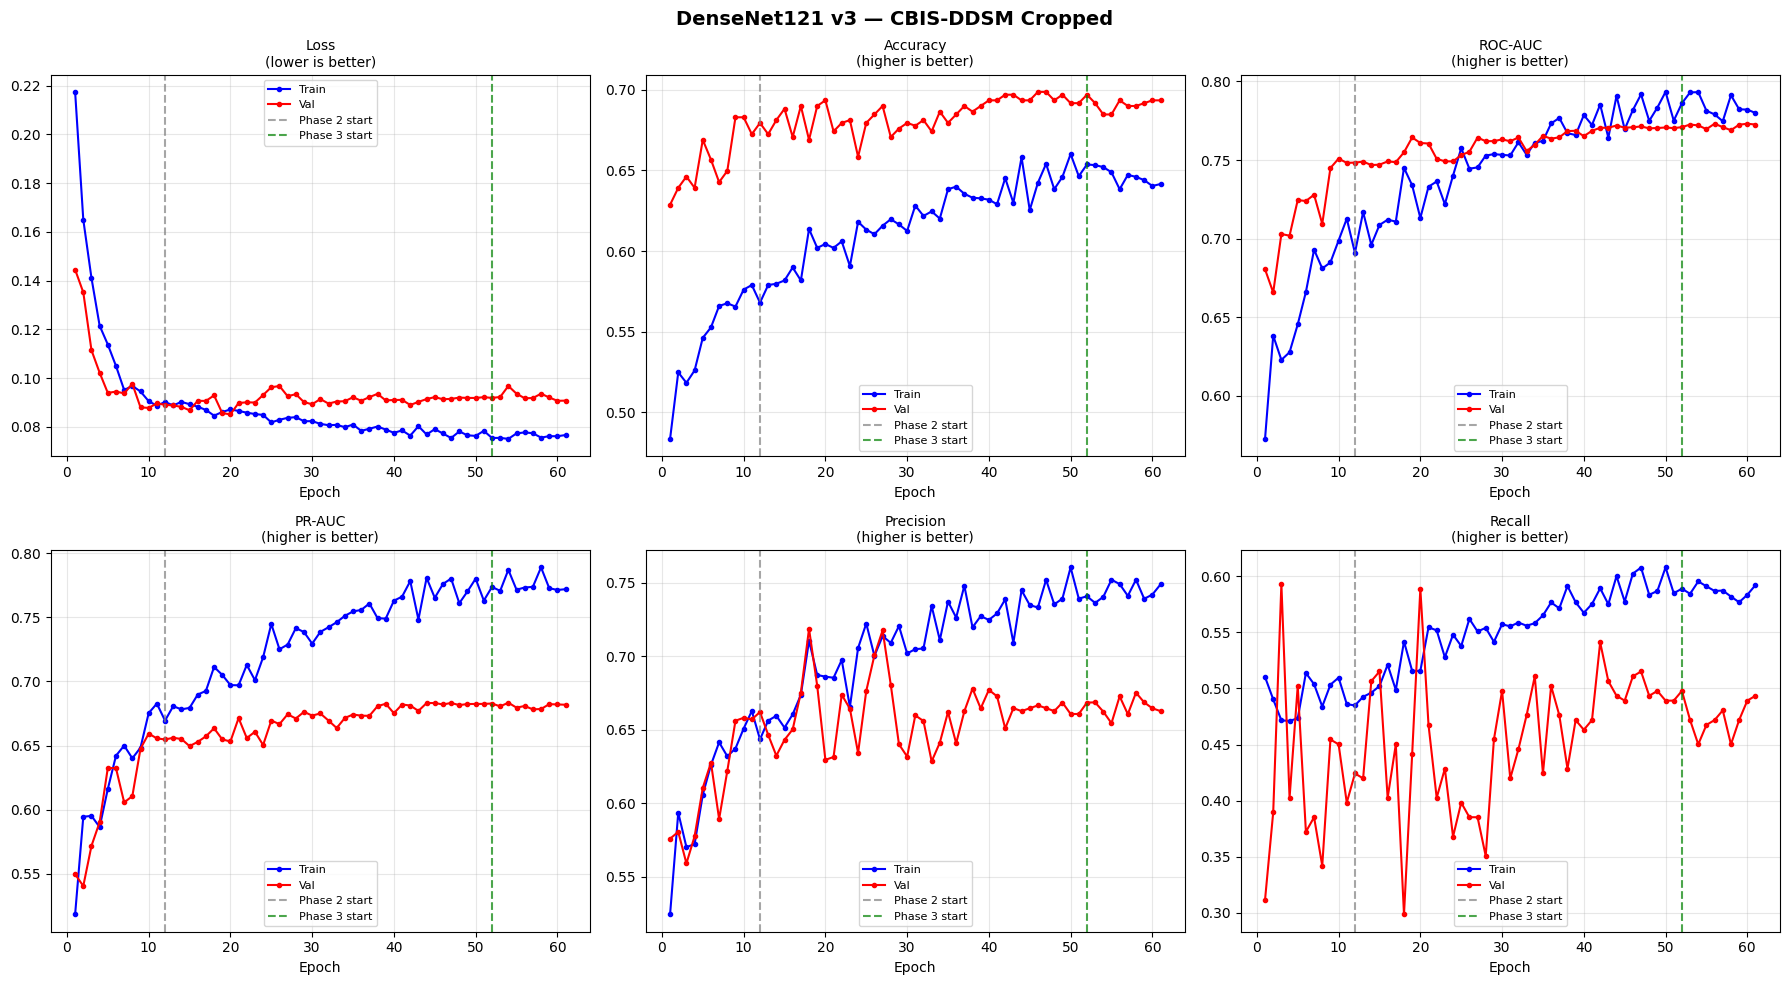

  Saved → /content/drive/MyDrive/THESIS/cbis-ddsm/model_output/densenet121_v3/training_history.png


In [11]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 11 ── Training history plot (3 phases)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def merge3(h1, h2, h3):
    keys = set(h1.history) | set(h2.history) | set(h3.history)
    return {k: list(h1.history.get(k,[])) + list(h2.history.get(k,[])) +
                list(h3.history.get(k,[])) for k in keys}

history = merge3(history_p1, history_p2, history_p3)
p1_end = len(history_p1.history["loss"])
p2_end = p1_end + len(history_p2.history["loss"])

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("DenseNet121 v3 — CBIS-DDSM Cropped", fontsize=14, fontweight="bold")
metrics_to_plot = [
    ("loss","val_loss","Loss","lower is better"),
    ("accuracy","val_accuracy","Accuracy","higher is better"),
    ("auc","val_auc","ROC-AUC","higher is better"),
    ("pr_auc","val_pr_auc","PR-AUC","higher is better"),
    ("precision","val_precision","Precision","higher is better"),
    ("recall","val_recall","Recall","higher is better"),
]
for ax, (tk, vk, title, note) in zip(axes.flat, metrics_to_plot):
    if tk not in history or vk not in history: continue
    ep = range(1, len(history[tk])+1)
    ax.plot(ep, history[tk], "b-o", ms=3, label="Train")
    ax.plot(ep, history[vk], "r-o", ms=3, label="Val")
    ax.axvline(p1_end, color="gray", ls="--", alpha=0.7, label="Phase 2 start")
    ax.axvline(p2_end, color="green", ls="--", alpha=0.7, label="Phase 3 start")
    ax.set_title(f"{title}\n({note})", fontsize=10); ax.set_xlabel("Epoch")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE_DIR / "training_history.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"  Saved → {SAVE_DIR / 'training_history.png'}")


▶  STEP 8 — TEST evaluation (TTA + multi-threshold) …

21/21 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step
  TTA view 1/8 …
  TTA view 2/8 …
  TTA view 3/8 …
  TTA view 4/8 …
  TTA view 5/8 …
  TTA view 6/8 …
  TTA view 7/8 …
  TTA view 8/8 …

  ──────────────────────────────────────────────────
  ROC-AUC (no-TTA) : 0.7996
  ROC-AUC (+TTA)   : 0.8162    ← official
  PR-AUC  (+TTA)   : 0.7813
  ──────────────────────────────────────────────────

  Threshold = 0.50
    Acc 0.7311  Sens 0.5907  Spec 0.8362  BalAcc 0.7135  F1 0.6530  MCC 0.4439
    TP=127  TN=240  FP=47  FN=88

  Threshold = Youden (0.429)
    Acc 0.7331  Sens 0.8140  Spec 0.6725  BalAcc 0.7432  F1 0.7231  MCC 0.4826
    TP=175  TN=193  FP=94  FN=40

  Threshold = F1-max (0.404)
    Acc 0.7211  Sens 0.8651  Spec 0.6132  BalAcc 0.7392  F1 0.7266  MCC 0.4816
    TP=186  TN=176  FP=111  FN=29

  Threshold = BalAcc (0.430)
    Acc 0.7291  Sens 0.8047  Spec 0.6725  BalAcc 0.7386  F1 0.7178  MCC 0.4732
    TP=173  TN=193  FP=94  FN=42

  ╔═

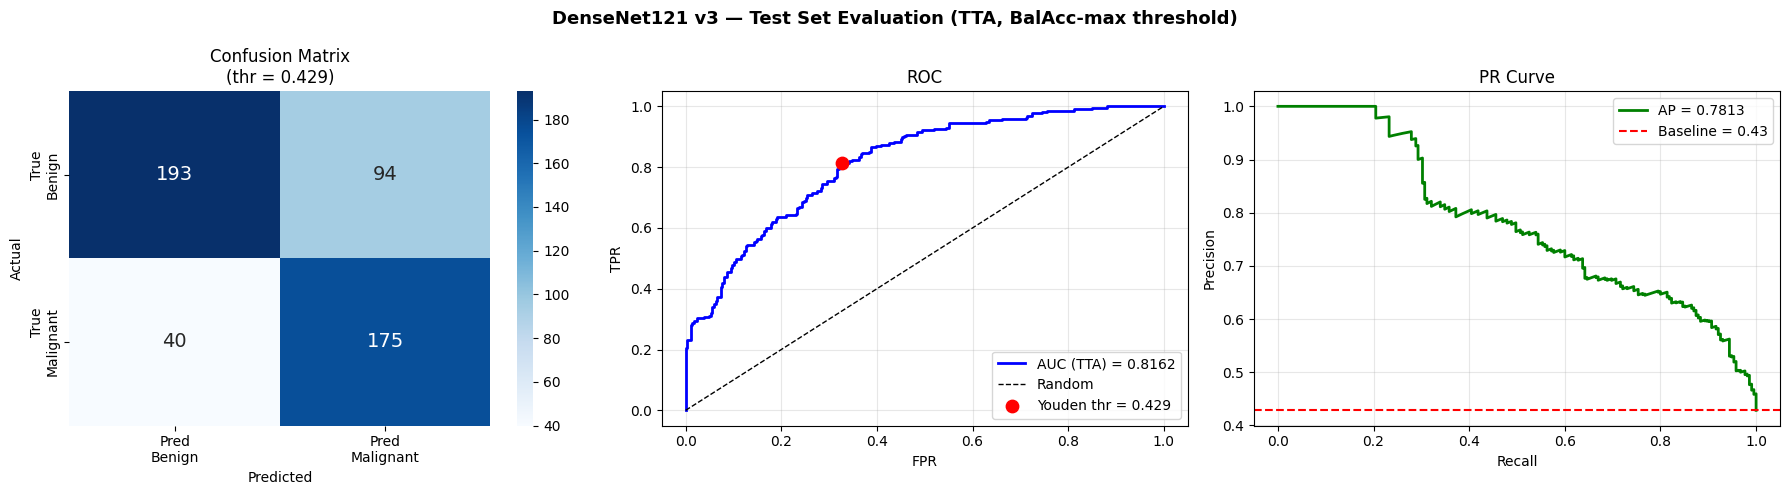

  Saved → /content/drive/MyDrive/THESIS/cbis-ddsm/model_output/densenet121_v3/evaluation_plots.png


In [12]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 12 ── TEST evaluation + TTA + multi-threshold (Youden / F1 / BalAcc)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n▶  STEP 8 — TEST evaluation (TTA + multi-threshold) …\n")

y_prob_std = model.predict(test_ds, verbose=1).flatten()
tta_probs = np.zeros_like(y_prob_std, dtype=np.float64)
for t in range(TTA_STEPS):
    print(f"  TTA view {t+1}/{TTA_STEPS} …")
    ds_tta = make_tta_ds(TEST_DIR, tf.constant(t, dtype=tf.int32))
    tta_probs += model.predict(ds_tta, verbose=0).flatten()
tta_probs /= TTA_STEPS
y_prob = tta_probs
y_true = np.array(test_labels, dtype=int)

# Threshold candidates
fpr, tpr, thr_roc = roc_curve(y_true, y_prob)
youden_j = tpr - fpr
thr_youden = float(thr_roc[np.argmax(youden_j)])

pr_p, pr_r, thr_pr = precision_recall_curve(y_true, y_prob)
f1s = 2 * pr_p * pr_r / (pr_p + pr_r + 1e-9)
thr_f1 = float(thr_pr[np.argmax(f1s[:-1])]) if len(thr_pr) > 0 else 0.5

# Balanced-accuracy max — sweep thresholds
best_ba, thr_ba = -1.0, 0.5
for t in np.linspace(0.05, 0.95, 181):
    yp = (y_prob >= t).astype(int)
    ba = balanced_accuracy_score(y_true, yp)
    if ba > best_ba:
        best_ba, thr_ba = ba, float(t)

thresholds = {
    "0.50"                  : 0.5,
    f"Youden ({thr_youden:.3f})"   : thr_youden,
    f"F1-max ({thr_f1:.3f})"        : thr_f1,
    f"BalAcc ({thr_ba:.3f})"        : thr_ba,
}

def metrics_at(thr):
    yp = (y_prob >= thr).astype(int)
    cm = confusion_matrix(y_true, yp); tn, fp, fn, tp = cm.ravel()
    acc  = (tp + tn) / len(y_true)
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    ppv  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    npv  = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    f1   = 2 * ppv * sens / (ppv + sens) if (ppv + sens) > 0 else 0.0
    bal  = 0.5 * (sens + spec)
    mcc  = matthews_corrcoef(y_true, yp)
    return dict(thr=thr, acc=acc, sens=sens, spec=spec, ppv=ppv, npv=npv,
                 f1=f1, bal=bal, mcc=mcc,
                 tp=int(tp), tn=int(tn), fp=int(fp), fn=int(fn))

auc_roc_std = roc_auc_score(y_true, y_prob_std)
auc_roc     = roc_auc_score(y_true, y_prob)
ap          = average_precision_score(y_true, y_prob)

print("\n  ──────────────────────────────────────────────────")
print(f"  ROC-AUC (no-TTA) : {auc_roc_std:.4f}")
print(f"  ROC-AUC (+TTA)   : {auc_roc:.4f}    ← official")
print(f"  PR-AUC  (+TTA)   : {ap:.4f}")
print("  ──────────────────────────────────────────────────\n")

rows = []; best_by_bal = None
for name, thr in thresholds.items():
    m = metrics_at(thr); rows.append({"threshold": name, **m})
    print(f"  Threshold = {name}")
    print(f"    Acc {m['acc']:.4f}  Sens {m['sens']:.4f}  Spec {m['spec']:.4f}  "
          f"BalAcc {m['bal']:.4f}  F1 {m['f1']:.4f}  MCC {m['mcc']:.4f}")
    print(f"    TP={m['tp']}  TN={m['tn']}  FP={m['fp']}  FN={m['fn']}\n")
    if best_by_bal is None or m["bal"] > best_by_bal["bal"]:
        best_by_bal = {"name": name, **m}

best = best_by_bal       # ← v3 selects by Balanced-Accuracy max
thr_metrics_df = pd.DataFrame(rows)
thr_metrics_df.to_csv(SAVE_DIR / "threshold_metrics.csv", index=False)

print("  ╔══════════════════════════════════════════════════════════════╗")
print(f"  ║  SELECTED  (BalAcc max — threshold = {best['name']})")
print("  ╚══════════════════════════════════════════════════════════════╝")
y_pred_best = (y_prob >= best["thr"]).astype(int)
print("  " + classification_report(y_true, y_pred_best,
      target_names=["benign","malignant"]).replace("\n", "\n  "))

# plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("DenseNet121 v3 — Test Set Evaluation (TTA, BalAcc-max threshold)",
              fontsize=13, fontweight="bold")
cm = confusion_matrix(y_true, y_pred_best)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred\nBenign","Pred\nMalignant"],
            yticklabels=["True\nBenign","True\nMalignant"],
            ax=axes[0], annot_kws={"size":14})
axes[0].set_title(f"Confusion Matrix\n(thr = {best['thr']:.3f})")
axes[0].set_ylabel("Actual"); axes[0].set_xlabel("Predicted")

axes[1].plot(fpr, tpr, "b-", lw=2, label=f"AUC (TTA) = {auc_roc:.4f}")
axes[1].plot([0,1],[0,1], "k--", lw=1, label="Random")
opt_idx = int(np.argmax(youden_j))
axes[1].scatter(fpr[opt_idx], tpr[opt_idx], color="red", s=80, zorder=5,
                label=f"Youden thr = {thr_youden:.3f}")
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR"); axes[1].set_title("ROC")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(pr_r, pr_p, "g-", lw=2, label=f"AP = {ap:.4f}")
axes[2].axhline(y_true.mean(), color="r", ls="--",
                label=f"Baseline = {y_true.mean():.2f}")
axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")
axes[2].set_title("PR Curve"); axes[2].legend(); axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE_DIR / "evaluation_plots.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"  Saved → {SAVE_DIR / 'evaluation_plots.png'}")


▶  STEP 9 — Grad-CAM …



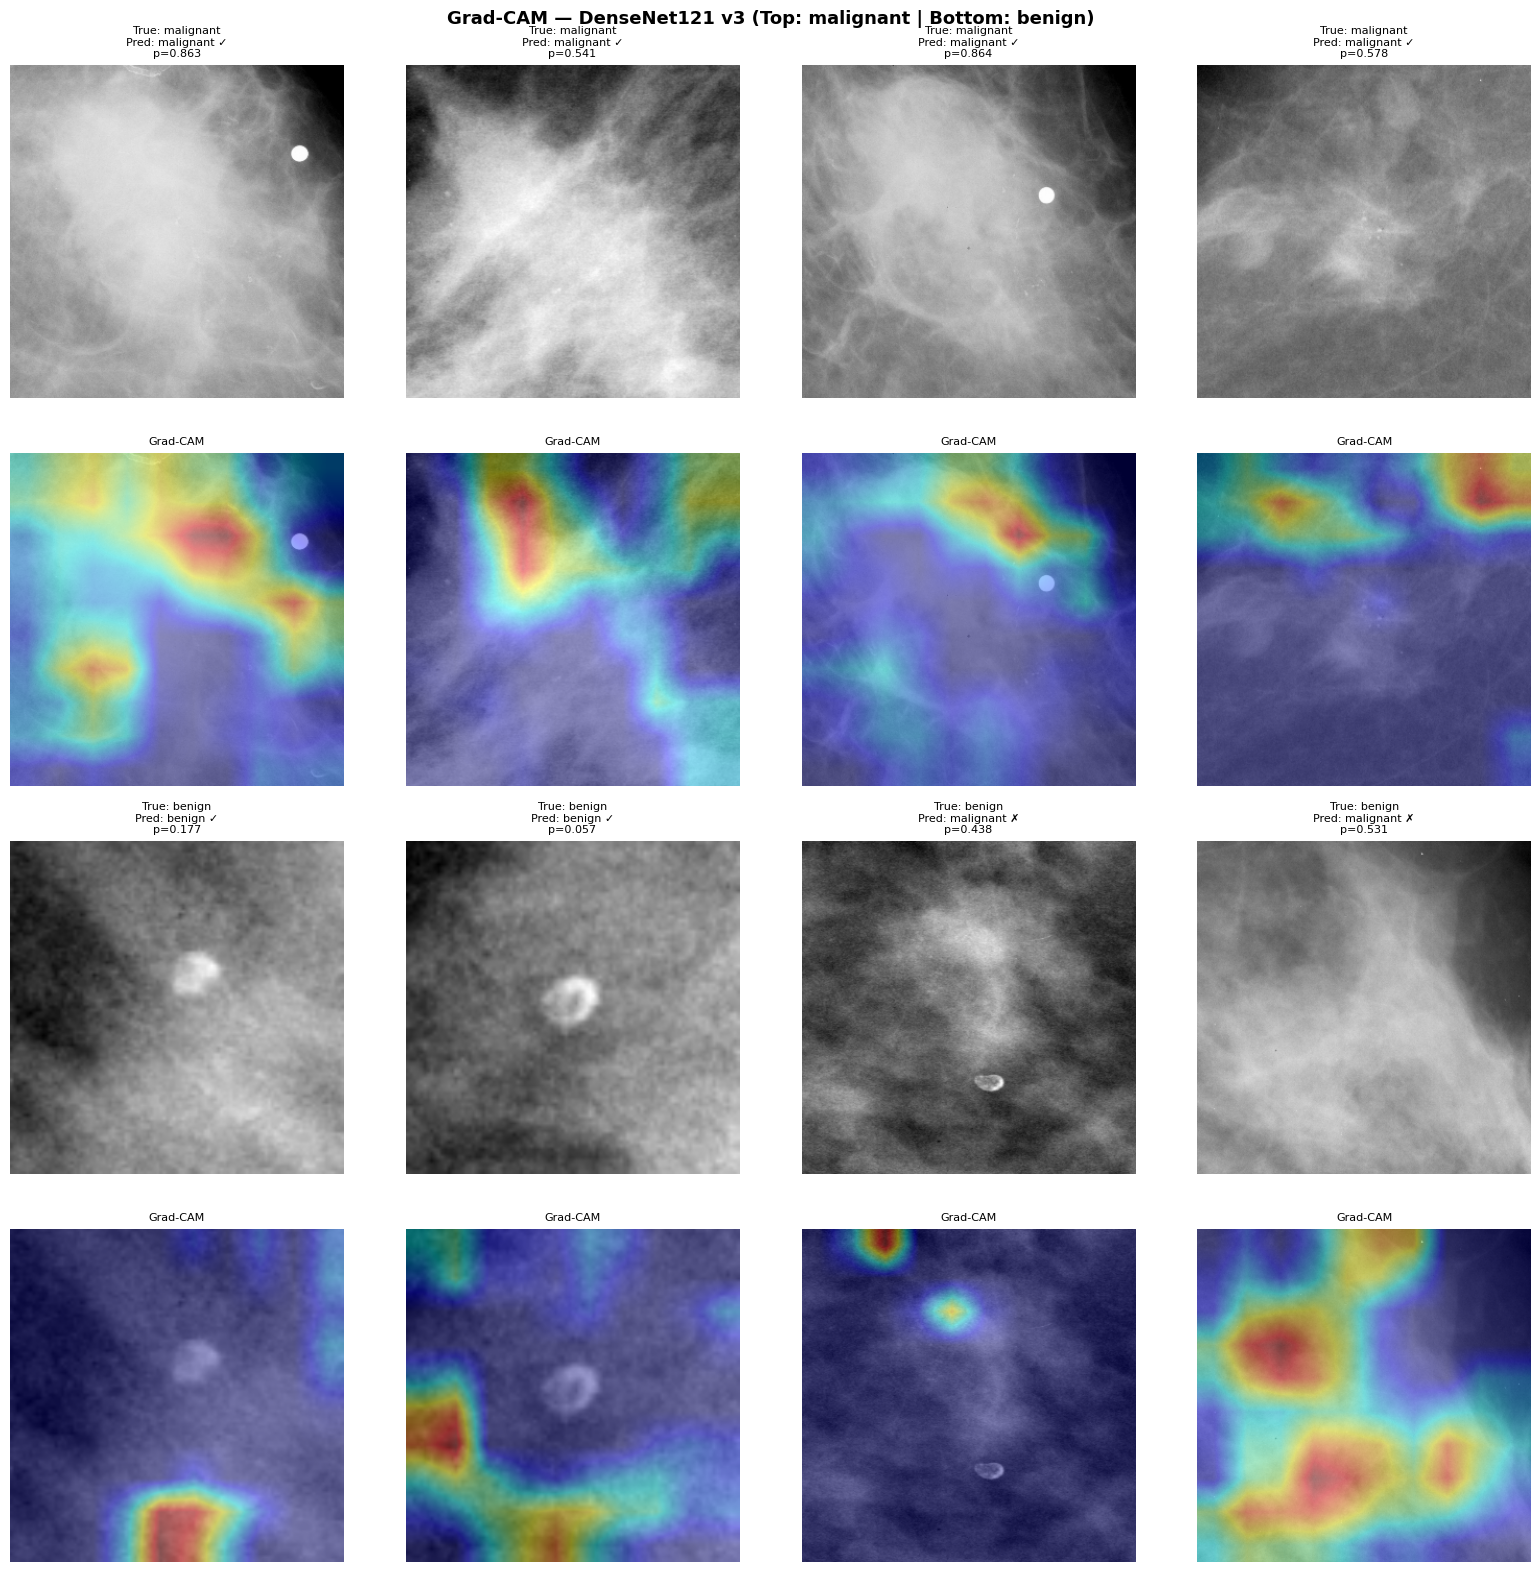

  Saved → /content/drive/MyDrive/THESIS/cbis-ddsm/model_output/densenet121_v3/gradcam_visualisation.png


In [13]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 13 ── Grad-CAM
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n▶  STEP 9 — Grad-CAM …\n")
LAST_CONV = "conv5_block16_2_conv"

def make_gradcam(img_array, target_model, last_conv=LAST_CONV):
    g = Model(inputs=target_model.inputs,
               outputs=[target_model.get_layer(last_conv).output, target_model.output])
    with tf.GradientTape() as tape:
        conv_out, preds = g(tf.cast(img_array, tf.float32))
        loss = preds[:, 0]
    grads = tape.gradient(loss, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0,1,2))
    h = conv_out[0] @ pooled[..., tf.newaxis]
    h = tf.squeeze(h)
    h = tf.maximum(h, 0) / (tf.reduce_max(h) + 1e-8)
    return h.numpy()

def overlay(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path); img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    h_u8 = np.uint8(255 * heatmap)
    h_col = cv2.applyColorMap(cv2.resize(h_u8, (IMG_SIZE, IMG_SIZE)), cv2.COLORMAP_JET)
    h_col = cv2.cvtColor(h_col, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(img, 1-alpha, h_col, alpha, 0), img

test_mal = [p for p, l in zip(test_paths, test_labels) if l == 1][:4]
test_ben = [p for p, l in zip(test_paths, test_labels) if l == 0][:4]
samples  = test_mal + test_ben; lbls = [1]*4 + [0]*4

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle("Grad-CAM — DenseNet121 v3 (Top: malignant | Bottom: benign)",
              fontsize=13, fontweight="bold")
for col, (img_path, true_lbl) in enumerate(zip(samples, lbls)):
    raw   = tf.io.read_file(img_path)
    img_t = tf.image.decode_jpeg(raw, channels=3)
    img_t = tf.image.resize(img_t, [RESIZE_SIZE, RESIZE_SIZE])
    img_n = img_t.numpy().astype(np.uint8); img_n = apply_clahe(img_n)
    off = (RESIZE_SIZE - IMG_SIZE) // 2
    img_n = img_n[off:off+IMG_SIZE, off:off+IMG_SIZE, :]
    img_p = preprocess_input(img_n.astype(np.float32))
    img_b = img_p[np.newaxis, ...]
    pred  = float(model.predict(img_b, verbose=0)[0][0])
    pname = "malignant" if pred >= best["thr"] else "benign"
    tname = "malignant" if true_lbl == 1 else "benign"
    mark  = "✓" if pname == tname else "✗"
    hm = make_gradcam(img_b, model)
    gcam, orig = overlay(img_path, hm)
    rt = 0 if col < 4 else 2; c = col % 4
    axes[rt, c].imshow(orig)
    axes[rt, c].set_title(f"True: {tname}\nPred: {pname} {mark}\np={pred:.3f}", fontsize=8)
    axes[rt, c].axis("off")
    axes[rt+1, c].imshow(gcam); axes[rt+1, c].set_title("Grad-CAM", fontsize=8)
    axes[rt+1, c].axis("off")
plt.tight_layout()
plt.savefig(SAVE_DIR / "gradcam_visualisation.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"  Saved → {SAVE_DIR / 'gradcam_visualisation.png'}")

In [14]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 14 ── Save results summary  + comparison vs v1 & v2
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n▶  STEP 10 — Saving results summary …")
results = {
    "model"              : "DenseNet121_v3",
    "dataset"            : "CBIS-DDSM cropped images",
    "img_size"           : IMG_SIZE,
    "batch_size"         : BATCH_SIZE,
    "phase1_epochs"      : len(history_p1.history["loss"]),
    "phase2_epochs"      : len(history_p2.history["loss"]),
    "phase3_epochs"      : len(history_p3.history["loss"]),
    "tta_steps"          : TTA_STEPS,
    "best_threshold"     : round(float(best["thr"]), 4),
    "threshold_strategy" : best["name"],
    "test_auc_roc_no_tta": round(auc_roc_std, 4),
    "test_auc_roc_tta"   : round(auc_roc,     4),
    "test_pr_auc_tta"    : round(ap,          4),
    "test_accuracy"      : round(best["acc"], 4),
    "test_balanced_acc"  : round(best["bal"], 4),
    "test_f1"            : round(best["f1"],  4),
    "test_precision"     : round(best["ppv"], 4),
    "test_recall_sensitivity": round(best["sens"], 4),
    "test_specificity"   : round(best["spec"], 4),
    "test_npv"           : round(best["npv"], 4),
    "test_mcc"           : round(best["mcc"], 4),
    "TP": int(best["tp"]), "TN": int(best["tn"]),
    "FP": int(best["fp"]), "FN": int(best["fn"]),
}
results_df = pd.DataFrame([results]).T
results_df.columns = ["Value"]
results_df.to_csv(SAVE_DIR / "results_summary.csv")
print(results_df.to_string())

# Comparison vs v1 (original) and v2 (your last run)
v1 = {"acc":0.6873, "auc":0.7622, "f1":0.6456, "prec":0.6272, "sens":0.6651,
      "spec":0.7038, "npv":0.7372}
v2 = {"acc":0.6713, "auc":0.7452, "f1":0.6833, "prec":0.5817, "sens":0.8279,
      "spec":0.5540, "npv":0.8112}
v3 = {"acc":best["acc"], "auc":auc_roc, "f1":best["f1"], "prec":best["ppv"],
      "sens":best["sens"], "spec":best["spec"], "npv":best["npv"]}
rows = []
for k in ["acc", "auc", "f1", "prec", "sens", "spec", "npv"]:
    d_v1 = v3[k] - v1[k]; d_v2 = v3[k] - v2[k]
    rows.append({"metric": k,
                  "v1": round(v1[k], 4), "v2": round(v2[k], 4),
                  "v3 (now)": round(v3[k], 4),
                  "Δ vs v1": f"{d_v1:+.4f}", "Δ vs v2": f"{d_v2:+.4f}"})
print("\n  ─── COMPARISON  v1 → v2 → v3 ───────────────────────────")
print(pd.DataFrame(rows).to_string(index=False))

print("\n" + "="*70)
print(f"  ALL FILES SAVED TO:  {SAVE_DIR}")
print("="*70)
print("  ✅  Training & evaluation complete!")


▶  STEP 10 — Saving results summary …
                                            Value
model                              DenseNet121_v3
dataset                  CBIS-DDSM cropped images
img_size                                      320
batch_size                                     24
phase1_epochs                                  12
phase2_epochs                                  40
phase3_epochs                                   9
tta_steps                                       8
best_threshold                             0.4295
threshold_strategy                 Youden (0.429)
test_auc_roc_no_tta                        0.7996
test_auc_roc_tta                           0.8162
test_pr_auc_tta                            0.7813
test_accuracy                              0.7331
test_balanced_acc                          0.7432
test_f1                                    0.7231
test_precision                             0.6506
test_recall_sensitivity                     0.814
test_specif

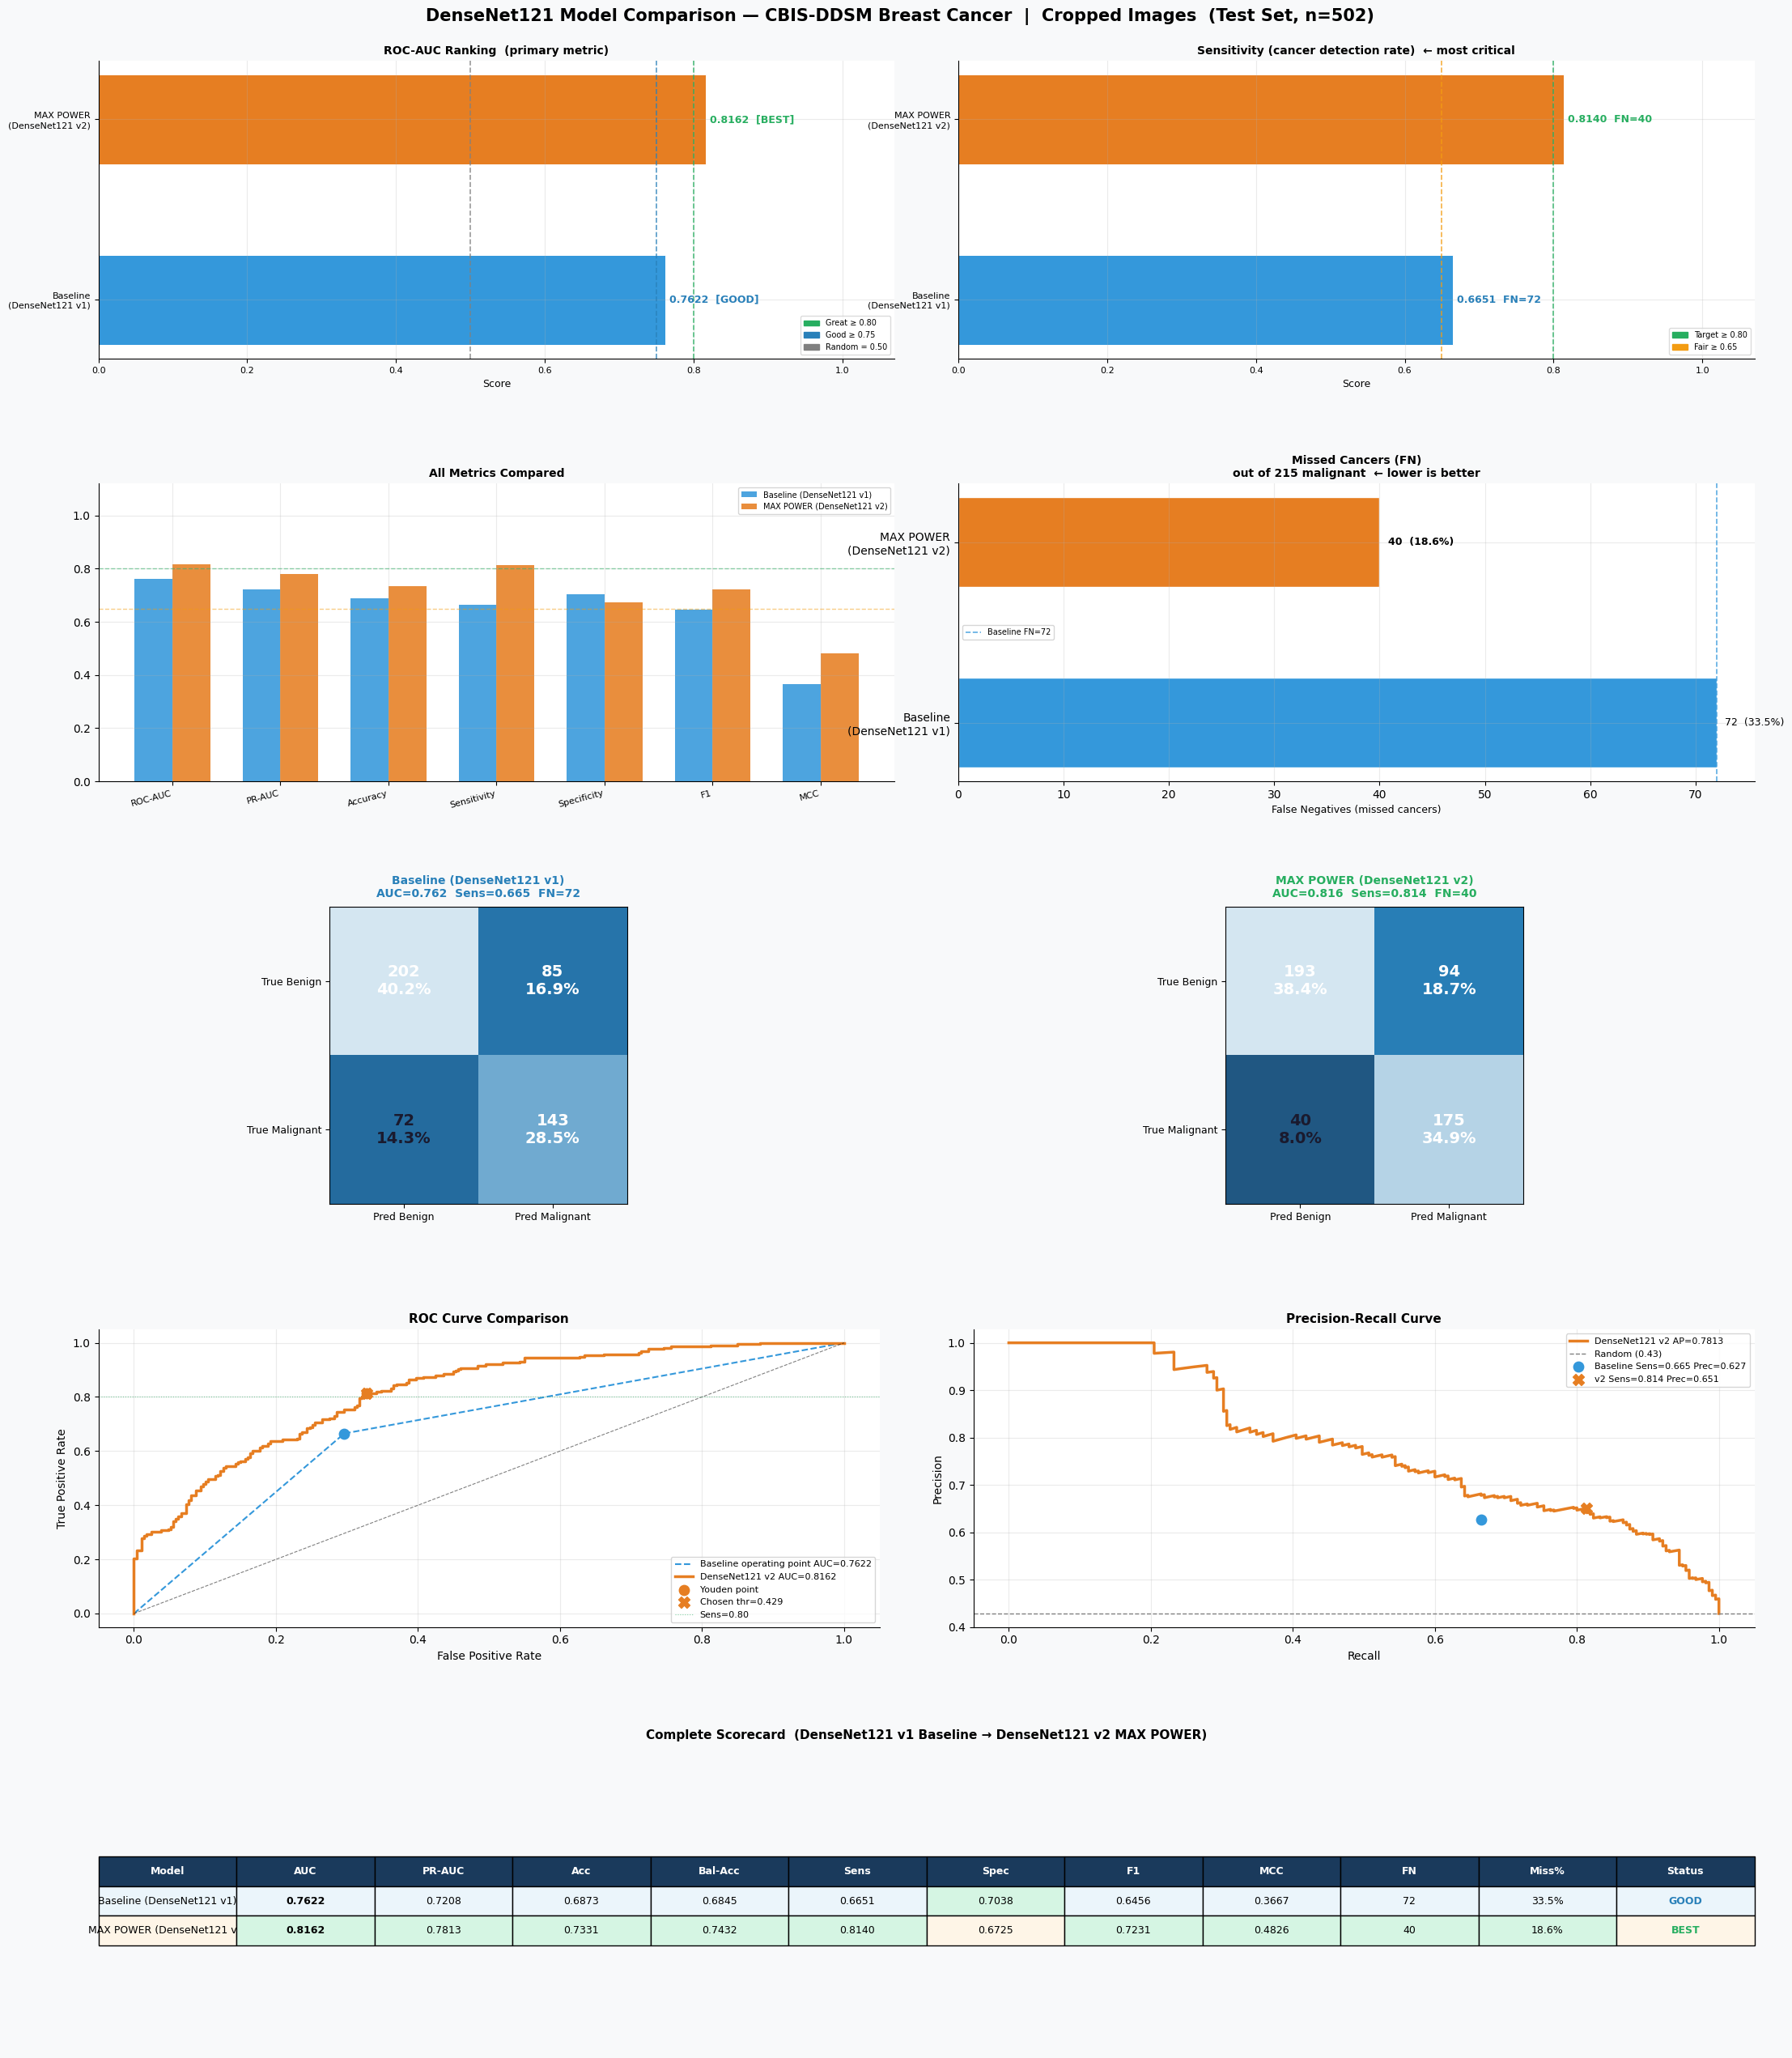

✅ DenseNet121 comparison dashboard saved → /content/drive/MyDrive/THESIS/cbis-ddsm/model_output/densenet121_v3/densenet121_comparison_dashboard.png


In [15]:
# ============================================================================
# CELL 14 / 16 - DenseNet121 Comparison Dashboard
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from pathlib import Path
from sklearn.metrics import roc_curve, precision_recall_curve

# ── Safety check ─────────────────────────────────────────────────────────────
_required = ["y_true", "y_prob", "best", "auc_roc", "ap", "SAVE_DIR"]
_missing = [v for v in _required if v not in globals()]
if _missing:
    raise RuntimeError(
        "Run the DenseNet121 evaluation + results cells first. "
        f"Missing variables: {_missing}"
    )

# ── Helpers ─────────────────────────────────────────────────────────────────
def status_color(auc):
    if auc >= 0.80:
        return "#27AE60"
    if auc >= 0.75:
        return "#2980B9"
    if auc >= 0.65:
        return "#F39C12"
    return "#E74C3C"

def status_label(auc):
    if auc >= 0.80:
        return "GREAT"
    if auc >= 0.75:
        return "GOOD"
    if auc >= 0.65:
        return "FAIR"
    return "FAILED"

def safe_mcc(tp, tn, fp, fn):
    denom = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    return 0.0 if denom == 0 else ((tp * tn) - (fp * fn)) / denom

def clean_ax(ax):
    ax.grid(alpha=0.25)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)

# ── Current DenseNet121 v2 metrics from notebook ─────────────────────────────
_tp = int(best["tp"])
_tn = int(best["tn"])
_fp = int(best["fp"])
_fn = int(best["fn"])

_prec = float(best.get("ppv", best.get("prec", _tp / (_tp + _fp))))
_sens = float(best["sens"])
_spec = float(best["spec"])
_acc  = float(best["acc"])
_f1   = float(best["f1"])
_thr  = float(best["thr"])
_mcc  = safe_mcc(_tp, _tn, _fp, _fn)

# ── Model registry ───────────────────────────────────────────────────────────
# Baseline DenseNet121 v1 values from uploaded 6-model final comparison image:
# AUC=.7622, PR-AUC=.7208, Acc=.6873, Sens=.6651, Spec=.7038,
# F1=.6456, MCC=.3667, TN=202, FP=85, FN=72, TP=143.
_b_tp, _b_tn, _b_fp, _b_fn = 143, 202, 85, 72

MODELS = {
    "Baseline\n(DenseNet121 v1)": dict(
        color="#3498DB",
        auc=0.7622,
        pr_auc=0.7208,
        acc=0.6873,
        sens=0.6651,
        spec=0.7038,
        prec=_b_tp / (_b_tp + _b_fp),
        f1=0.6456,
        mcc=0.3667,
        fn=_b_fn,
        tp=_b_tp,
        tn=_b_tn,
        fp=_b_fp,
        n_mal=_b_tp + _b_fn,
        thr=None,
    ),
    "MAX POWER\n(DenseNet121 v2)": dict(
        color="#E67E22",
        auc=float(auc_roc),
        pr_auc=float(ap),
        acc=_acc,
        sens=_sens,
        spec=_spec,
        prec=_prec,
        f1=_f1,
        mcc=_mcc,
        fn=_fn,
        tp=_tp,
        tn=_tn,
        fp=_fp,
        n_mal=_tp + _fn,
        thr=_thr,
    ),
}

names = list(MODELS.keys())
colors = [MODELS[n]["color"] for n in names]
best_auc_name = max(names, key=lambda n: MODELS[n]["auc"])

def display_status(nm):
    return "BEST" if nm == best_auc_name else status_label(MODELS[nm]["auc"])

n_test_total = _tp + _tn + _fp + _fn
n_malignant = _tp + _fn

# ── Figure layout ────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 26), facecolor="#F8F9FA")
fig.suptitle(
    f"DenseNet121 Model Comparison — CBIS-DDSM Breast Cancer  |  Cropped Images"
    f"  (Test Set, n={n_test_total})",
    fontsize=15,
    fontweight="bold",
    y=0.99,
)

outer = gridspec.GridSpec(
    5, 1, figure=fig,
    hspace=0.42,
    top=0.965,
    bottom=0.02,
    left=0.05,
    right=0.98,
)

# ── ROW 0: AUC ranking | sensitivity ranking ────────────────────────────────
row0 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[0], wspace=0.08)
ax_auc = fig.add_subplot(row0[0])
ax_sens = fig.add_subplot(row0[1])

rank_auc = sorted(names, key=lambda n: MODELS[n]["auc"], reverse=True)
rank_sens = sorted(names, key=lambda n: MODELS[n]["sens"], reverse=True)

for ax, metric, order, title, reflines in [
    (
        ax_auc,
        "auc",
        rank_auc,
        "ROC-AUC Ranking  (primary metric)",
        [
            (0.80, "#27AE60", "Great ≥ 0.80"),
            (0.75, "#2980B9", "Good ≥ 0.75"),
            (0.50, "gray", "Random = 0.50"),
        ],
    ),
    (
        ax_sens,
        "sens",
        rank_sens,
        "Sensitivity (cancer detection rate)  ← most critical",
        [
            (0.80, "#27AE60", "Target ≥ 0.80"),
            (0.65, "#F39C12", "Fair ≥ 0.65"),
        ],
    ),
]:
    vals = [MODELS[n][metric] for n in order]
    cols = [MODELS[n]["color"] for n in order]

    bars = ax.barh(order, vals, color=cols, height=0.5, edgecolor="white", linewidth=0.7)
    ax.invert_yaxis()

    for bar, val, nm in zip(bars, vals, order):
        sc = status_color(MODELS[nm]["auc"])
        label = (
            f"{val:.4f}  [{display_status(nm)}]"
            if metric == "auc"
            else f"{val:.4f}  FN={MODELS[nm]['fn']}"
        )
        ax.text(
            val + 0.005,
            bar.get_y() + bar.get_height() / 2,
            label,
            va="center",
            fontsize=9,
            color=sc,
            fontweight="bold",
        )

    for xv, c, lbl in reflines:
        ax.axvline(xv, color=c, ls="--", lw=1.2, alpha=0.8)

    ax.set_xlim(0, 1.07)
    ax.set_title(title, fontsize=10, fontweight="bold", pad=6)
    ax.tick_params(labelsize=8)
    ax.set_xlabel("Score", fontsize=9)
    clean_ax(ax)

    handles = [mpatches.Patch(color=c, label=lbl) for _, c, lbl in reflines]
    ax.legend(handles=handles, fontsize=7, loc="lower right", framealpha=0.7)

# ── ROW 1: all metrics | missed cancers ─────────────────────────────────────
row1 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[1], wspace=0.08)
ax_multi = fig.add_subplot(row1[0])
ax_fn = fig.add_subplot(row1[1])

MK = ["auc", "pr_auc", "acc", "sens", "spec", "f1", "mcc"]
MLBL = ["ROC-AUC", "PR-AUC", "Accuracy", "Sensitivity", "Specificity", "F1", "MCC"]

x = np.arange(len(MK))
bw = 0.35

for i, nm in enumerate(names):
    vals = [MODELS[nm][k] for k in MK]
    ax_multi.bar(
        x + (i - 0.5) * bw,
        vals,
        bw,
        color=MODELS[nm]["color"],
        alpha=0.88,
        label=nm.replace("\n", " "),
    )

ax_multi.set_xticks(x)
ax_multi.set_xticklabels(MLBL, rotation=15, ha="right", fontsize=8)
ax_multi.set_ylim(0, 1.12)
ax_multi.set_title("All Metrics Compared", fontsize=10, fontweight="bold")
ax_multi.legend(fontsize=7, loc="upper right")
ax_multi.axhline(0.80, color="#27AE60", ls="--", lw=1, alpha=0.5)
ax_multi.axhline(0.65, color="#F39C12", ls="--", lw=1, alpha=0.5)
clean_ax(ax_multi)

rank_fn = sorted(names, key=lambda n: MODELS[n]["fn"])
fn_vals = [MODELS[n]["fn"] for n in rank_fn]
fn_cols = [MODELS[n]["color"] for n in rank_fn]

fn_bars = ax_fn.barh(rank_fn, fn_vals, color=fn_cols, height=0.5, edgecolor="white")
ax_fn.invert_yaxis()

for bar, fn, nm in zip(fn_bars, fn_vals, rank_fn):
    n_mal = MODELS[nm]["n_mal"]
    ax_fn.text(
        fn + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{fn}  ({fn / n_mal * 100:.1f}%)",
        va="center",
        fontsize=9,
        fontweight="bold" if nm == "MAX POWER\n(DenseNet121 v2)" else "normal",
    )

ax_fn.axvline(
    _b_fn,
    color=MODELS["Baseline\n(DenseNet121 v1)"]["color"],
    ls="--",
    lw=1.2,
    alpha=0.8,
    label=f"Baseline FN={_b_fn}",
)
ax_fn.set_title(
    f"Missed Cancers (FN)\nout of {n_malignant} malignant  ← lower is better",
    fontsize=10,
    fontweight="bold",
)
ax_fn.set_xlabel("False Negatives (missed cancers)", fontsize=9)
ax_fn.legend(fontsize=7)
clean_ax(ax_fn)

# ── ROW 2: confusion matrices ───────────────────────────────────────────────
row2 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[2], wspace=0.18)
cmap_cm = LinearSegmentedColormap.from_list(
    "cm_dashboard",
    ["#1A3A5C", "#2980B9", "#D4E6F1"],
)

for i, nm in enumerate(names):
    d = MODELS[nm]
    cm_arr = np.array([[d["tn"], d["fp"]], [d["fn"], d["tp"]]])
    n = cm_arr.sum()

    ax = fig.add_subplot(row2[i])
    ax.imshow(cm_arr, cmap=cmap_cm, vmin=0, vmax=max(cm_arr.max(), 1))

    for r in range(2):
        for c in range(2):
            val = cm_arr[r, c]
            ax.text(
                c,
                r,
                f"{val}\n{val / n * 100:.1f}%",
                ha="center",
                va="center",
                fontsize=14,
                fontweight="bold",
                color="white" if val > cm_arr.max() * 0.4 else "#1A1A2E",
            )

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred Benign", "Pred Malignant"], fontsize=9)
    ax.set_yticklabels(["True Benign", "True Malignant"], fontsize=9)
    ax.set_title(
        f"{nm.replace(chr(10), ' ')}\n"
        f"AUC={d['auc']:.3f}  Sens={d['sens']:.3f}  FN={d['fn']}",
        fontsize=10,
        fontweight="bold",
        color=status_color(d["auc"]),
        pad=8,
    )

# ── ROW 3: ROC and PR curves ────────────────────────────────────────────────
row3 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[3], wspace=0.12)
ax_roc = fig.add_subplot(row3[0])
ax_pr = fig.add_subplot(row3[1])

y_true_dash = np.asarray(y_true).astype(int)
y_prob_dash = np.asarray(y_prob).astype(float)

fpr_new, tpr_new, thr_new = roc_curve(y_true_dash, y_prob_dash)
youden_idx = int(np.argmax(tpr_new - fpr_new))

pr_precision, pr_recall, _ = precision_recall_curve(y_true_dash, y_prob_dash)
random_pr = y_true_dash.mean()

b = MODELS["Baseline\n(DenseNet121 v1)"]
n = MODELS["MAX POWER\n(DenseNet121 v2)"]

# Baseline raw probabilities are not available from the image, so this is an
# operating-point proxy using the baseline confusion matrix.
ax_roc.plot(
    [0, 1 - b["spec"], 1],
    [0, b["sens"], 1],
    "--",
    color=b["color"],
    lw=1.5,
    label=f"Baseline operating point AUC={b['auc']:.4f}",
)
ax_roc.scatter(
    [1 - b["spec"]],
    [b["sens"]],
    color=b["color"],
    s=80,
    zorder=5,
)

ax_roc.plot(
    fpr_new,
    tpr_new,
    "-",
    color=n["color"],
    lw=2.5,
    label=f"DenseNet121 v2 AUC={n['auc']:.4f}",
)
ax_roc.scatter(
    [fpr_new[youden_idx]],
    [tpr_new[youden_idx]],
    color=n["color"],
    s=80,
    zorder=5,
    label=f"Youden point",
)
ax_roc.scatter(
    [1 - n["spec"]],
    [n["sens"]],
    marker="X",
    color=n["color"],
    s=100,
    zorder=6,
    label=f"Chosen thr={n['thr']:.3f}",
)

ax_roc.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
ax_roc.axhline(0.80, color="#27AE60", ls=":", lw=0.8, alpha=0.6, label="Sens=0.80")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("ROC Curve Comparison", fontsize=11, fontweight="bold")
ax_roc.legend(fontsize=8)
clean_ax(ax_roc)

ax_pr.plot(
    pr_recall,
    pr_precision,
    "-",
    color=n["color"],
    lw=2.5,
    label=f"DenseNet121 v2 AP={n['pr_auc']:.4f}",
)
ax_pr.axhline(random_pr, color="gray", ls="--", lw=1, label=f"Random ({random_pr:.2f})")

ax_pr.scatter(
    [b["sens"]],
    [b["prec"]],
    color=b["color"],
    s=80,
    zorder=5,
    label=f"Baseline Sens={b['sens']:.3f} Prec={b['prec']:.3f}",
)
ax_pr.scatter(
    [n["sens"]],
    [n["prec"]],
    color=n["color"],
    marker="X",
    s=100,
    zorder=6,
    label=f"v2 Sens={n['sens']:.3f} Prec={n['prec']:.3f}",
)

ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_title("Precision-Recall Curve", fontsize=11, fontweight="bold")
ax_pr.legend(fontsize=8)
clean_ax(ax_pr)

# ── ROW 4: scorecard table ─────────────────────────────────────────────────
ax_tbl = fig.add_subplot(outer[4])
ax_tbl.axis("off")

COLS = [
    "Model",
    "AUC",
    "PR-AUC",
    "Acc",
    "Bal-Acc",
    "Sens",
    "Spec",
    "F1",
    "MCC",
    "FN",
    "Miss%",
    "Status",
]

rows_data = []
for nm in names:
    d = MODELS[nm]
    bal_acc = (d["sens"] + d["spec"]) / 2
    rows_data.append([
        nm.replace("\n", " "),
        f"{d['auc']:.4f}",
        f"{d['pr_auc']:.4f}",
        f"{d['acc']:.4f}",
        f"{bal_acc:.4f}",
        f"{d['sens']:.4f}",
        f"{d['spec']:.4f}",
        f"{d['f1']:.4f}",
        f"{d['mcc']:.4f}",
        str(d["fn"]),
        f"{d['fn'] / d['n_mal'] * 100:.1f}%",
        display_status(nm),
    ])

tbl = ax_tbl.table(cellText=rows_data, colLabels=COLS, loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.0, 2.2)

# Header
for j in range(len(COLS)):
    tbl[(0, j)].set_facecolor("#1A3A5C")
    tbl[(0, j)].set_text_props(color="white", fontweight="bold")

row_bg = ["#EBF5FB", "#FEF5E7"]
for i, nm in enumerate(names):
    sc = status_color(MODELS[nm]["auc"])
    for j in range(len(COLS)):
        cell = tbl[(i + 1, j)]
        cell.set_facecolor(row_bg[i])
        if j == 1:
            cell.set_text_props(fontweight="bold")
        if j == len(COLS) - 1:
            cell.set_text_props(color=sc, fontweight="bold")

# Highlight winners
higher_is_better = {1, 2, 3, 4, 5, 6, 7, 8}
lower_is_better = {9, 10}

for col_idx in range(1, len(COLS) - 1):
    raw = []
    for r in range(len(names)):
        txt = tbl[(r + 1, col_idx)].get_text().get_text().replace("%", "")
        raw.append(float(txt))

    if col_idx in higher_is_better:
        best_val = max(raw)
    elif col_idx in lower_is_better:
        best_val = min(raw)
    else:
        continue

    for r, val in enumerate(raw):
        if abs(val - best_val) < 1e-9:
            tbl[(r + 1, col_idx)].set_facecolor("#D5F5E3")

ax_tbl.set_title(
    "Complete Scorecard  (DenseNet121 v1 Baseline → DenseNet121 v2 MAX POWER)",
    fontsize=11,
    fontweight="bold",
    pad=12,
    y=1.0,
)

# ── Save ────────────────────────────────────────────────────────────────────
save_path = Path(SAVE_DIR) / "densenet121_comparison_dashboard.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="#F8F9FA")
plt.show()

print(f"✅ DenseNet121 comparison dashboard saved → {save_path}")